Note: "WFHL" or Weight-for-Height/Length Sheet for Wasting and “HLFA” or Height/Length-For-Age Sheet for Stunting

In [64]:
import pandas as pd
import unicodedata
import re

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import matplotlib.font_manager as fm

font_path = "Microsoft Aptos Fonts/Aptos.ttf"  
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()

import os


# Read WFHL and HLFA Data

We care about `WSW_Percent` (relative count of moderately wasted and severely wasted) for `WFHL` and `STSST_Percent` (relative count of stunted and severely stunted) for `HLFA`.

In [42]:
# deal with wfa
wfhl_df = pd.read_excel(
    '1.-2025-OPT-Plus-Report-as-of-18March2026_locked.xlsx',
    sheet_name='WFHL', 
    skiprows=6
)

wfhl_df.columns

relevant_wfa_cols = ['PSGC', 'Actual_children', '05BW', '05GW', '611BW',
       '611GW', '1213BW', '1223GW', '2435BW', '2435GW', '3647BW', '3647GW',
       '4859BW', '4859GW', 'W_Number', 'W_Coverage', '05BSW', '05GSW',
       '611BSW', '611GSW', '1213BSW', '1223GSW', '2435BSW', '2435GSW',
       '3647BSW', '3647GSW', '4859BSW', '4859GSW', 'SW_Number', 'SW_Total',
       'WSW_Number', 'WSW_Percent']
wfhl_df = wfhl_df[relevant_wfa_cols]

In [43]:
# deal with HLFA
hlfa_df = pd.read_excel(
    '1.-2025-OPT-Plus-Report-as-of-18March2026_locked.xlsx',
    sheet_name='HLFA', 
    skiprows=6
)

hlfa_df.columns

relevant_hlfa_cols = ['PSGC', 'Geographic Level', 'Region', 'Province', 'CityMun', '05BST', '05GST', '611BST',
       '611GST', '1223BST', '1223GST', '2435BST', '2435GST', '3647BST',
       '3647GST', '4859BST', '4859GST', 'ST_Number', 'ST_Coverage', '05BSST',
       '05GSST', '611BSST', 'STSST_Number', 'STSST_Percent']
hlfa_df = hlfa_df[relevant_hlfa_cols]


national_df = pd.merge(hlfa_df, wfhl_df, on='PSGC')

# Combine with Population Census and Income Data

In [44]:
# population census data
popcen_df = pd.read_excel('popcen.xlsx', skiprows=4).dropna(subset=['PSGC'])[['PSGC', 'Total2024', 'Total2020', 'Urban2024', 'Urban2020']]
national_df = pd.merge(national_df, popcen_df, on='PSGC')

In [45]:
# income data
income_df = pd.read_excel('income.xlsx')
income_df['NEW CLASS'] = income_df['NEW CLASS'].replace({
    '2nd*': '2nd',
    '3rd*': '3rd',
    'Sth':'5th'
})

def normalize(text):    
    text = str(text).lower()
    
    # remove accents (ñ → n)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # remove things in parentheses such as "(Capital)"
    text = re.sub(r'\(.*?\)', '', text)
    
    # remove prefixes/suffixes
    text = re.sub(
        r'\b(city of|province of|municipality of|city|province|municipality)\b',
        '',
        text
    )
    
    # remove punctuation
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

national_df['lgu_clean'] = national_df['CityMun'].apply(normalize)
national_df['prov_clean'] = national_df['Province'].apply(normalize)

income_df['lgu_clean'] = income_df['LGU NAME'].apply(normalize)
income_df['prov_clean'] = income_df['Province Name'].apply(normalize)

national_df = national_df.merge(
    income_df[['lgu_clean', 'prov_clean', 'NEW CLASS']],
    on=['lgu_clean', 'prov_clean'],
    how='left'
)

# CHOROPLETH ON THE COUNTRIES for WASTING & STUNTING

In [34]:
DOH_THRESHOLD = 0.05
national_df['above_threshold_WSW'] = national_df['WSW_Percent'] > 0.05
national_df['above_threshold_STSST'] = national_df['STSST_Percent'] > 0.1
prov_df = national_df[(national_df['Geographic Level'] == 'Prov')]

folder_path = 'faeldon philippines-json-maps master 2023-geojson_regions/hires'

gdfs = []

# Loop through all json files
for file in os.listdir(folder_path):
    if file.endswith('.json'):
        path = os.path.join(folder_path, file)
        gdf = gpd.read_file(path)
        gdfs.append(gdf)

# Combine into one GeoDataFrame
geo_df = pd.concat(gdfs, ignore_index=True)

prov_geo_df = geo_df.merge(
    prov_df,
    left_on='adm2_en',
    right_on='Province',
    how='left'
)

In [59]:
regional_df = national_df.groupby('Region')[['WSW_Number', 'STSST_Number', 'Actual_children']].sum()
regional_df['WSW_Percent'] = regional_df.WSW_Number / regional_df.Actual_children
regional_df['STSST_Percent'] = regional_df.STSST_Number / regional_df.Actual_children
regional_df.sort_values(by='WSW_Percent', ascending=False)

,WSW_Number,STSST_Number,Actual_children,WSW_Percent,STSST_Percent
Region,,,,,
MIMAROPA Region,16295.0,69962.0,551471.0,0.029548,0.126864
Region V (Bicol Region),31275.0,142391.0,1466888.0,0.021321,0.097070
Region VIII (Eastern Visayas),15293.0,92839.0,824924.0,0.018539,0.112542
Region IV-A (CALABARZON),64870.0,193750.0,4626862.0,0.014020,0.041875
Region IX (Zamboanga Peninsula),8661.0,32342.0,618707.0,0.013999,0.052274
Region III (Central Luzon),46863.0,131805.0,3460109.0,0.013544,0.038093
Region XIII (Caraga),5309.0,28820.0,457809.0,0.011597,0.062952
Region VII (Central Visayas),21445.0,127439.0,1932594.0,0.011096,0.065942
Region II (Cagayan Valley),6210.0,23204.0,612542.0,0.010138,0.037881


In [60]:
regional_df.sort_values(by='STSST_Percent', ascending=False)

,WSW_Number,STSST_Number,Actual_children,WSW_Percent,STSST_Percent
Region,,,,,
MIMAROPA Region,16295.0,69962.0,551471.0,0.029548,0.126864
Region VIII (Eastern Visayas),15293.0,92839.0,824924.0,0.018539,0.112542
Region V (Bicol Region),31275.0,142391.0,1466888.0,0.021321,0.097070
Region VII (Central Visayas),21445.0,127439.0,1932594.0,0.011096,0.065942
Bangsamoro Autonomous Region In Muslim Mindanao (BARMM),9483.0,70468.0,1088345.0,0.008713,0.064748
Region XIII (Caraga),5309.0,28820.0,457809.0,0.011597,0.062952
Cordillera Administrative Region (CAR),2274.0,17498.0,297794.0,0.007636,0.058759
Region IX (Zamboanga Peninsula),8661.0,32342.0,618707.0,0.013999,0.052274
Region XI (Davao Region),5383.0,35905.0,721645.0,0.007459,0.049754


In [98]:
regional_df.sort_values(by='STSST_Percent', ascending=False).sum()

WSW_Number         2.650750e+05
STSST_Number       1.118736e+06
Actual_children    2.171736e+07
WSW_Percent        1.993250e-01
STSST_Percent      9.607916e-01
dtype: float64

In [99]:
2.650750e+05/2.171736e+07


0.012205673249418897

In [101]:
1.118736e+06/2.171736e+07

0.0515134436229818

In [94]:
regional_df.describe()

,WSW_Number,STSST_Number,Actual_children,WSW_Percent,STSST_Percent
count,17.000000,17.000000,1.700000e+01,17.000000,17.000000
mean,15592.647059,65808.000000,1.277492e+06,0.011725,0.056517
std,17116.281923,53320.648683,1.134250e+06,0.006474,0.030311
min,2274.000000,17498.000000,2.977940e+05,0.004203,0.016188
25%,5383.000000,25222.000000,6.187070e+05,0.007483,0.037881
50%,8437.000000,36767.000000,8.672040e+05,0.010138,0.049754
75%,16295.000000,92839.000000,1.350240e+06,0.013999,0.064748
max,64870.000000,193750.000000,4.626862e+06,0.029548,0.126864


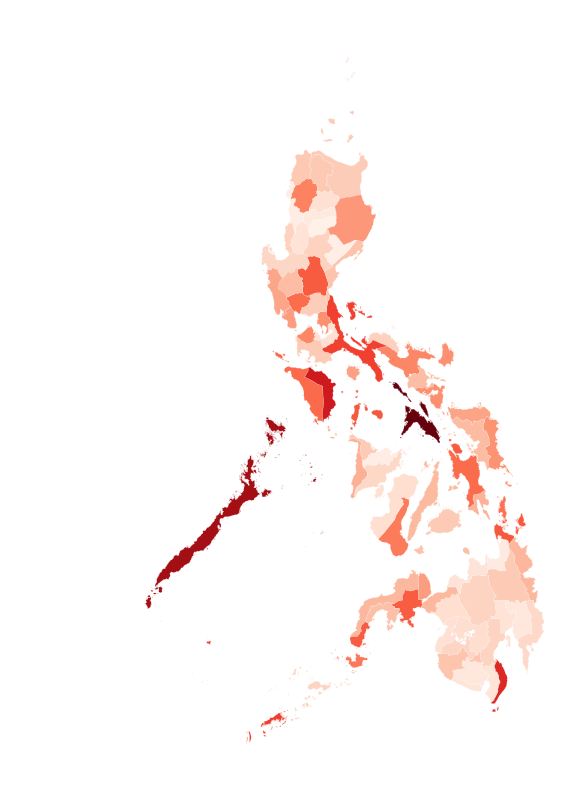

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

prov_geo_df.plot(
    column='WSW_Percent', 
    cmap="Reds",       
    linewidth=0.1,
    edgecolor='white',
    legend=False,
    vmin=0,
    ax=ax
)

# cbar = ax.get_figure().get_axes()[1]  # colorbar axis
# cbar.yaxis.set_major_formatter(PercentFormatter(1.0))  

#ax.set_title("WSW Percentage by Province", fontsize=14)
ax.axis('off')

plt.show()

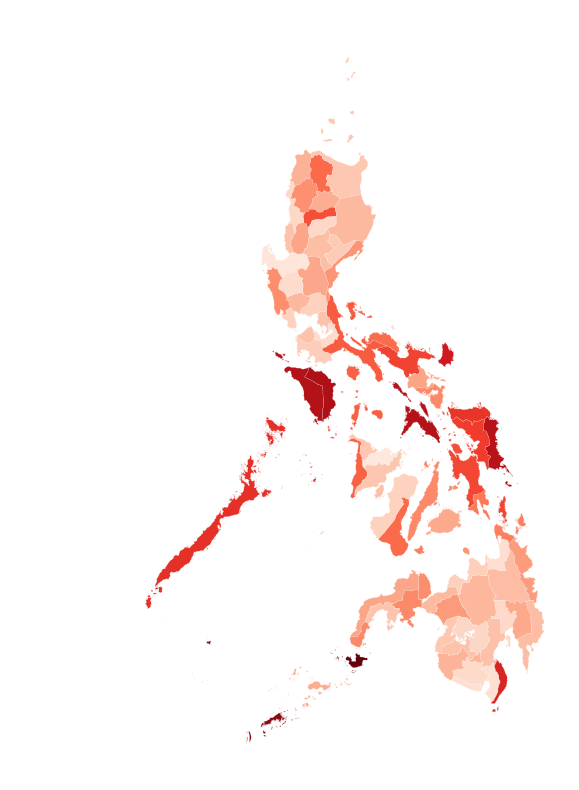

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

prov_geo_df.plot(
    column='STSST_Percent', 
    cmap="Reds",       
    linewidth=0.1,
    edgecolor='white',
    legend=False,
    vmin=0,
    ax=ax
)

# cbar = ax.get_figure().get_axes()[1]  # colorbar axis
# cbar.yaxis.set_major_formatter(PercentFormatter(1.0))  
# for label in cbar.get_yticklabels():
#     label.set_fontproperties(prop)
    
#ax.set_title("WSW Percentage by Province", fontsize=14, fontproperties=prop)
ax.axis('off')

plt.show()

# POP CENSUS

In [9]:
lgu_df = national_df[(national_df['Geographic Level'] != 'Prov') & (national_df['Geographic Level'] != 'Reg')].copy()
lgu_df = lgu_df[['Province', 'CityMun', 'WSW_Percent', 'STSST_Percent', 'Total2020', 'Total2024', 'NEW CLASS']]
lgu_df['Total_Growth'] = (lgu_df.Total2024 - lgu_df.Total2020) / lgu_df.Total2020

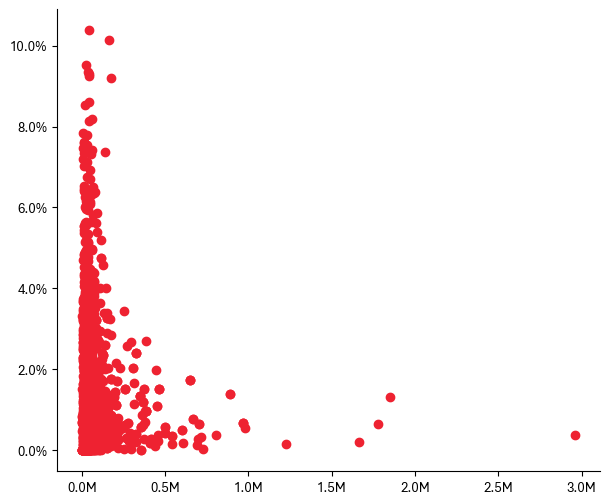

In [91]:
plt.figure(figsize=(7, 6))

plt.scatter(lgu_df.Total2020, lgu_df.WSW_Percent, color="#ee2231")

# X-axis in millions with "M"
def millions(x, pos):
    return f'{x/1_000_000:.1f}M'

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))

# Y-axis as percent
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

#plt.xlabel("Population (Millions)")
#plt.ylabel("WSW Percentage")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

Quezon City, Manila, Davao

In [97]:
lgu_df[lgu_df.Total2024 > 1_000_000].sort_values(by='Total2024', ascending=False)

,Province,CityMun,WSW_Percent,STSST_Percent,Total2020,Total2024,NEW CLASS,Total_Growth,Income_Label
1579,NaN,Quezon City,0.003682,0.008050,2960048.0,3084270.0,1st,0.041966,≥₱1500M
1572,NaN,City of Manila,0.013263,0.052369,1846513.0,1902590.0,1st,0.030369,≥₱1500M
1472,Davao del Sur,City of Davao,0.006489,0.056117,1776949.0,1848947.0,1st,0.040518,≥₱1500M
1567,NaN,City of Caloocan,0.001954,0.013601,1661584.0,1712945.0,1st,0.030911,≥₱1500M
1581,NaN,City of Taguig,0.001614,0.002042,1223595.0,1308085.0,1st,0.069051,≥₱1500M
1332,Zamboanga del Sur,City of Zamboanga,0.005521,0.018563,977234.0,1018849.0,1st,0.042584,≥₱1500M


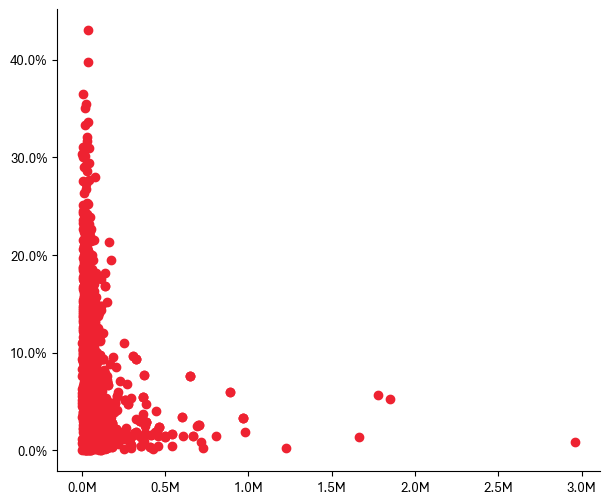

In [92]:
plt.figure(figsize=(7, 6))

plt.scatter(lgu_df.Total2020, lgu_df.STSST_Percent, color="#ee2231")

# X-axis in millions with "M"
def millions(x, pos):
    return f'{x/1_000_000:.1f}M'

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))

# Y-axis as percent
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

#plt.xlabel("Population (Millions)")
#plt.ylabel("WSW Percentage")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

# INCOME

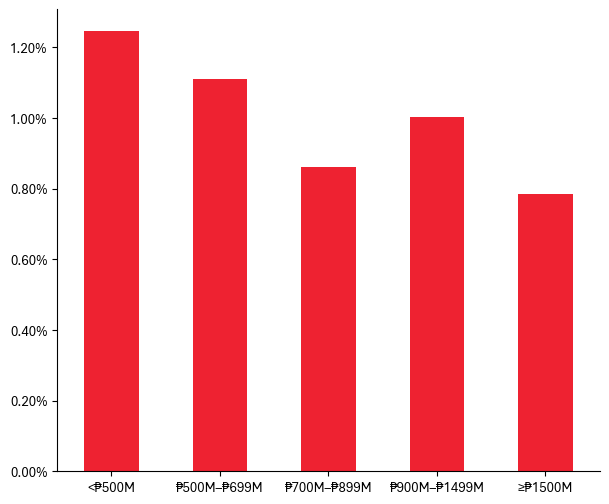

In [87]:
income_map = {
    '1st': '≥₱1500M',
    '2nd': '₱900M–₱1499M',
    '3rd': '₱700M–₱899M',
    '4th': '₱500M–₱699M',
    '5th': '<₱500M'
}

lgu_df['Income_Label'] = lgu_df['NEW CLASS'].map(income_map)
order = ['<₱500M', '₱500M–₱699M', '₱700M–₱899M', '₱900M–₱1499M', '≥₱1500M']
lgu_df['Income_Label'] = pd.Categorical(lgu_df['Income_Label'], categories=order, ordered=True)

plt.figure(figsize=(7, 6))

lgu_df.groupby('Income_Label', observed=True)['WSW_Percent'].median().plot(
    kind='bar',
    color='#ee2231',

)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0)) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('')

plt.show()

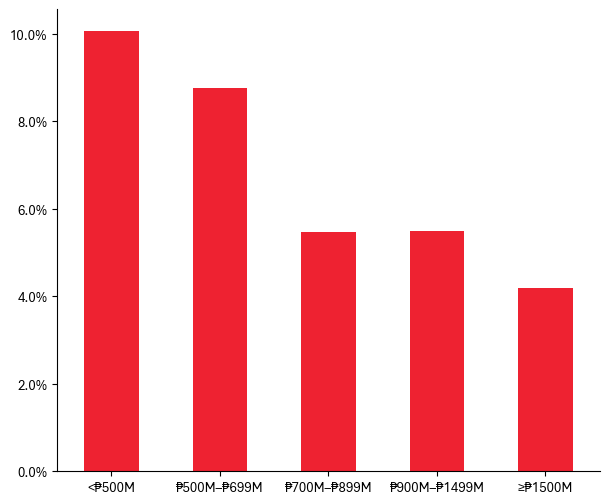

In [93]:
plt.figure(figsize=(7, 6))

lgu_df.groupby('Income_Label', observed=True)['STSST_Percent'].median().plot(
    kind='bar',
    color='#ee2231',

)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0)) 

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(rotation=0)
plt.xlabel('')
plt.ylabel('')

plt.show()